# Feature-Space Shift Analysis with TaP + DCAMA

This notebook reproduces the feature-space shift visualisation from §3.3 of the paper.
At each outer adaptation iteration we:
1. Run the query image through the *current* (LoRA-adapted) encoder and record the **spatial feature map**.
2. Do the same for every support image.
3. Sample class-labelled pixels from the feature maps using the GT masks.
4. Project everything to 2D with **t-SNE** and overlay on the segmentation prediction.

> Requires: DCAMA checkpoints + `assets/episode/episode.pt` (saved by the demo notebook).

## 1. Imports

In [1]:
import os, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
from copy import deepcopy
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from peft import LoraConfig

if os.path.basename(os.getcwd()) != 'TakeAPeek':
    os.chdir('..')

from tap import TakeAPeek
from tap.validate import get_dcama
from tap.adapters import get_peft_model
from tap.substitutor import Substitutor
from tap.loss import FSSLoss
from torch.optim import AdamW

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

# ── visualisation helpers (same palette as the demo notebook) ─────────────────
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t):
    return (t.cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)

# Distinct colours per class: background, A-query, A-support, B-query, B-support
CLASS_COLOURS = {
    'bg':        np.array([0.55, 0.55, 0.55]),
    'A_query':   np.array([0.85, 0.15, 0.15]),
    'A_support': np.array([0.98, 0.65, 0.65]),
    'B_query':   np.array([0.15, 0.35, 0.85]),
    'B_support': np.array([0.65, 0.75, 0.98]),
}

SEG_PALETTE = np.array([[0.5,0.5,0.5],[0.9,0.2,0.2],[0.2,0.4,0.9]])

def mask_to_rgb(m):
    return SEG_PALETTE[np.clip(m.cpu().numpy().astype(int),0,len(SEG_PALETTE)-1)]

def resize_mask(mask_hw, H, W):
    return F.interpolate(
        mask_hw.float().unsqueeze(0).unsqueeze(0),
        size=(H, W), mode='nearest').long().squeeze()

def overlay(img_chw, mask_hw, orig_hw=None, alpha=0.45):
    img = denorm(img_chw).permute(1,2,0).numpy()
    H, W = img.shape[:2]
    if orig_hw is not None:
        oh, ow = orig_hw
        mask_hw = mask_hw[:oh, :ow]
    if tuple(mask_hw.shape) != (H, W):
        mask_hw = resize_mask(mask_hw, H, W)
    return img*(1-alpha) + mask_to_rgb(mask_hw)*alpha

/home/pasquale/projects/TakeAPeek/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load DCAMA

In [2]:
model, image_size = get_dcama(dataset='coco', val_fold_idx=0)
model = model.to(DEVICE)
print(f'Backbone: {model.backbone}, image size: {image_size}')

Backbone: swin, image size: 384


## 3. TaP configuration

In [3]:
LORA_CFG = LoraConfig(
    r=64, lora_alpha=64.0,
    target_modules=['qkv'],
    lora_dropout=0.1,
    bias='none',
)
NUM_ITER = 10
LR       = 1e-3
N_PIX    = 100   # pixels sampled per class per image for t-SNE

tap = TakeAPeek(model=model, lora_config=LORA_CFG,
                num_iterations=NUM_ITER, lr=LR, device=DEVICE)

## 4. Load episode

In [4]:
EPISODE_DIR = 'assets/episode'

ckpt  = torch.load(os.path.join(EPISODE_DIR, 'episode.pt'),
                   map_location=DEVICE, weights_only=False)
batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
         for k, v in ckpt['batch'].items()}
gt    = ckpt['gt'].to(DEVICE)

B, M, C, H, W = batch['images'].shape
N_WAYS  = ckpt.get('n_ways', 2)
K_SHOTS = (M - 1) // N_WAYS
print(f'images: {tuple(batch["images"].shape)}   N_WAYS={N_WAYS}, K_SHOTS={K_SHOTS}')

images: (1, 7, 3, 384, 384)   N_WAYS=2, K_SHOTS=3


## 5. Feature extraction and pixel-sampling helpers

In [5]:
def get_encoder(peft_model):
    """Unwrap PEFT to reach the base DCAMA whose extract_feats carries LoRA weights."""
    try:
        return peft_model.base_model.model
    except AttributeError:
        return peft_model


def extract_last_scale(peft_model, img_bchw):
    """Return the last-scale feature map: (B, C_feat, H', W').
    The last Swin scale is the most semantically rich (1024 channels).
    """
    base = get_encoder(peft_model)
    with torch.no_grad():
        feats = base.extract_feats(img_bchw)   # list of (B, C_i, H_i, W_i)
    return feats[-1]                            # (B, 1024, H/32, W/32)


def sample_pixels(feat_map, mask_hw, class_ids, n=N_PIX):
    """Sample `n` feature vectors per class_id from `feat_map`.

    Args:
        feat_map : (1, C, Hf, Wf) – encoder output for one image
        mask_hw  : (Hm, Wm)       – integer class mask (original resolution)
        class_ids: list[int]       – class values to sample (e.g. [1, 2])
        n        : pixels per class

    Returns:
        dict {class_id: np.ndarray (n, C)}
    """
    _, C, Hf, Wf = feat_map.shape
    # Resize mask to feature-map resolution
    mask_f = resize_mask(mask_hw.cpu(), Hf, Wf).numpy()         # (Hf, Wf)
    feat_flat = feat_map[0].permute(1,2,0).reshape(-1, C).cpu().numpy()  # (Hf*Wf, C)

    out = {}
    for cid in class_ids:
        idx = np.where(mask_f.reshape(-1) == cid)[0]
        if len(idx) == 0:
            out[cid] = None
            continue
        chosen = np.random.choice(idx, size=min(n, len(idx)), replace=False)
        out[cid] = feat_flat[chosen]           # (n, C)
    return out

## 6. Run TaP with feature capture

Replays the exact TaP adaptation loop but records the encoder output and segmentation logits at every outer iteration's query pass.

In [6]:
def run_tap_analysis(model, lora_cfg, batch, gt,
                     num_iterations=NUM_ITER, lr=LR, device=DEVICE):
    """
    Returns a list of dicts, one per outer iteration:
        pred          : (B, H', W') int — argmax of logits
        query_feat    : (1, C, Hf, Wf)  — last-scale encoder features for query
        support_feats : list[(1, C, Hf, Wf)]  — one per support image
    """
    lora_model = get_peft_model(deepcopy(model), lora_cfg)
    tap._set_adapt_mode(lora_model)
    lora_model = lora_model.to(device)
    optimizer  = AdamW(lora_model.parameters(), lr=lr)
    loss_fn    = FSSLoss(class_weighting=True, components={'focal': {'weight': 1.0}})
    sub        = Substitutor()

    records = []

    for k in range(num_iterations):
        sub.reset((batch, gt))
        for i, (step_batch, step_gt) in enumerate(sub):
            optimizer.zero_grad()
            if i == 0:
                lora_model.eval()
                with torch.no_grad():
                    # segmentation prediction
                    res  = lora_model(step_batch)
                    pred = res['logits'].argmax(dim=1).cpu()

                    # encoder features (query + all support)
                    q_img = step_batch['images'][:, 0]          # (B,3,H,W)
                    s_imgs = step_batch['images'][:, 1:]         # (B,N*K,3,H,W)
                    q_feat = extract_last_scale(lora_model, q_img)
                    s_feats = [extract_last_scale(lora_model, s_imgs[:, j])
                               for j in range(s_imgs.shape[1])]

                records.append({
                    'pred':          pred,
                    'query_feat':    q_feat.cpu(),
                    'support_feats': [f.cpu() for f in s_feats],
                })
                tap._set_adapt_mode(lora_model)
            else:
                res = lora_model(step_batch)
                loss_fn(res, step_gt).backward()
                optimizer.step()

    return records


print('Running TaP analysis (may take a minute)…')
records = run_tap_analysis(model, LORA_CFG, batch, gt)
print(f'Captured {len(records)} iterations.')

Running TaP analysis (may take a minute)…
Captured 10 iterations.


## 7. Build the t-SNE projections

In [7]:
# Ground-truth masks (original resolution, one per image)
images    = batch['images'][0]       # (M, 3, H, W)
gts       = gt[0].cpu()             # (M, H', W')
dims      = batch['dims'][0].cpu()  # (M, 2)

q_gt      = gts[0]                  # (H', W')
s_gts     = gts[1:]                 # (N*K, H', W')
q_orig_hw = dims[0].tolist()

# Class ids: 0=bg, 1=class A, 2=class B
CLASS_IDS = [1, 2]

tsne_data = []   # one entry per iteration

for k, rec in enumerate(records):
    q_feat    = rec['query_feat']       # (1, C, Hf, Wf)
    s_feats   = rec['support_feats']    # list of (1, C, Hf, Wf)

    # Crop GT to original dims before sampling
    qh, qw = q_orig_hw
    q_gt_crop = q_gt[:qh, :qw]

    # Sample query pixels by class
    q_samples = sample_pixels(q_feat, q_gt_crop, CLASS_IDS)

    # Sample support pixels (each support image has its own GT)
    s_samples = {cid: [] for cid in CLASS_IDS}
    for j, s_feat in enumerate(s_feats):
        sh, sw = dims[j+1].tolist()
        s_gt_crop = s_gts[j][:sh, :sw]
        sp = sample_pixels(s_feat, s_gt_crop, CLASS_IDS)
        for cid in CLASS_IDS:
            if sp[cid] is not None:
                s_samples[cid].append(sp[cid])

    # Stack all vectors + labels for t-SNE
    vecs, labels, groups = [], [], []
    for cid in CLASS_IDS:
        letter = 'A' if cid == 1 else 'B'
        if q_samples[cid] is not None:
            vecs.append(q_samples[cid])
            labels += [cid] * len(q_samples[cid])
            groups += [f'{letter}_query'] * len(q_samples[cid])
        for s in s_samples[cid]:
            vecs.append(s)
            labels += [cid] * len(s)
            groups += [f'{letter}_support'] * len(s)

    if not vecs:
        tsne_data.append(None)
        continue

    X = np.vstack(vecs)

    # PCA → 50 dims first (standard t-SNE preprocessing)
    n_pca = min(50, X.shape[0] - 1, X.shape[1])
    X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X)

    X_2d = TSNE(n_components=2, perplexity=min(30, len(X_pca)-1),
                random_state=42, n_iter=500).fit_transform(X_pca)

    tsne_data.append({'X_2d': X_2d, 'groups': groups})
    print(f'  iter {k}: t-SNE done ({len(X)} points)')

  iter 0: t-SNE done (204 points)
  iter 1: t-SNE done (204 points)
  iter 2: t-SNE done (204 points)
  iter 3: t-SNE done (204 points)
  iter 4: t-SNE done (204 points)
  iter 5: t-SNE done (204 points)
  iter 6: t-SNE done (204 points)
  iter 7: t-SNE done (204 points)
  iter 8: t-SNE done (204 points)
  iter 9: t-SNE done (204 points)


## 8. Segmentation evolution across iterations

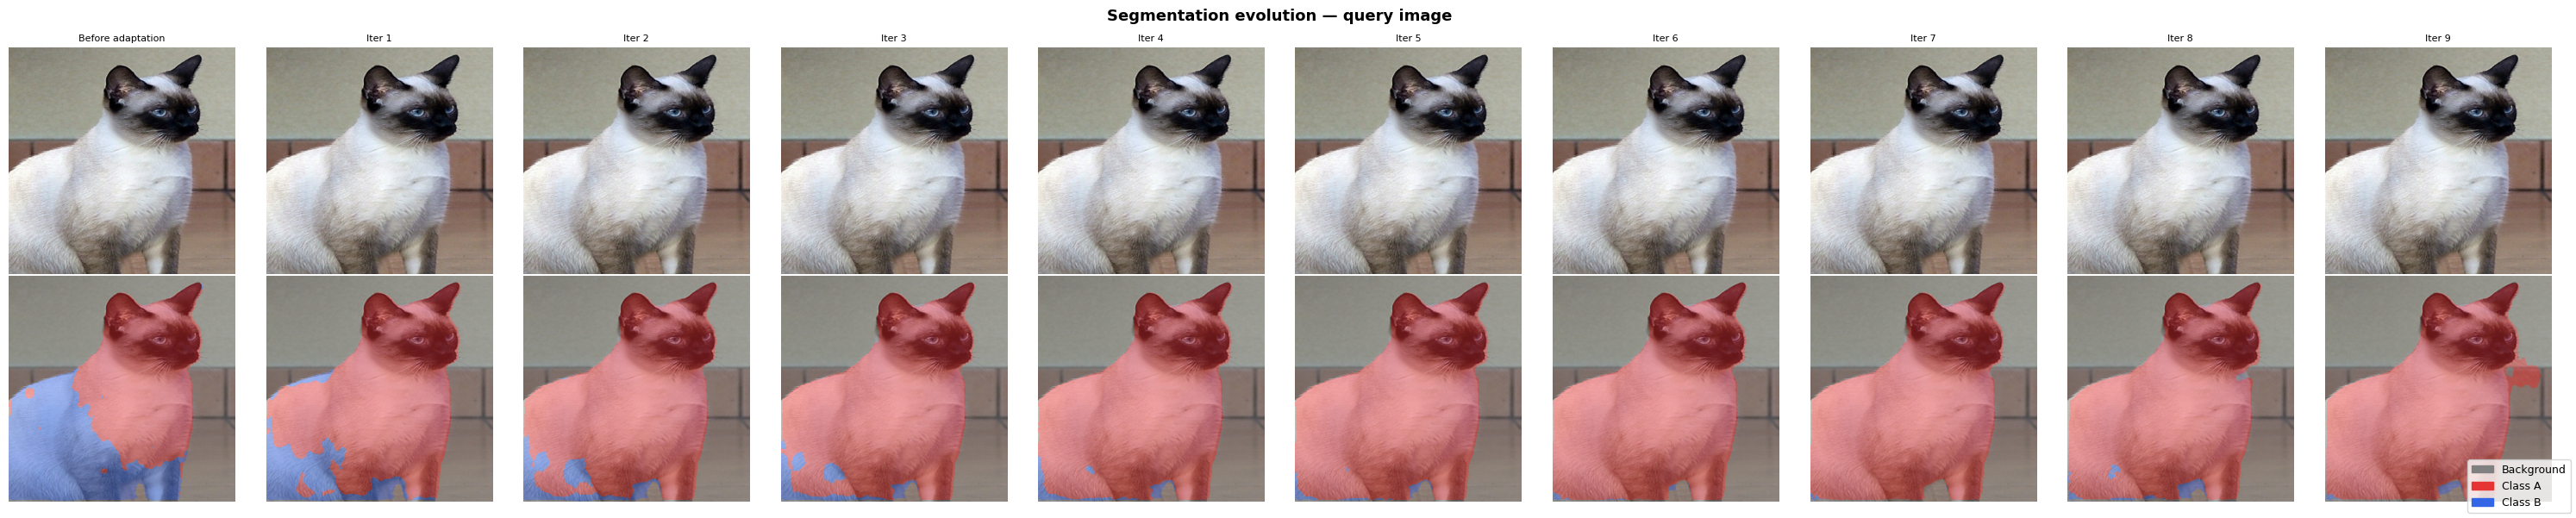

In [8]:
q_img    = images[0]
q_gt_cpu = q_gt.cpu()
qh, qw   = q_orig_hw

fig, axes = plt.subplots(2, NUM_ITER, figsize=(3*NUM_ITER, 6))
fig.suptitle('Segmentation evolution — query image', fontsize=13, fontweight='bold')

for k, rec in enumerate(records):
    label = 'Before adaptation' if k == 0 else f'Iter {k}'
    axes[0, k].imshow(denorm(q_img).permute(1,2,0))
    axes[0, k].set_title(label, fontsize=8)
    axes[0, k].axis('off')

    axes[1, k].imshow(overlay(q_img, rec['pred'][0], orig_hw=(qh, qw)))
    axes[1, k].axis('off')

legend = [
    mpatches.Patch(color=SEG_PALETTE[0], label='Background'),
    mpatches.Patch(color=SEG_PALETTE[1], label='Class A'),
    mpatches.Patch(color=SEG_PALETTE[2], label='Class B'),
]
fig.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Feature-space shift — t-SNE across iterations

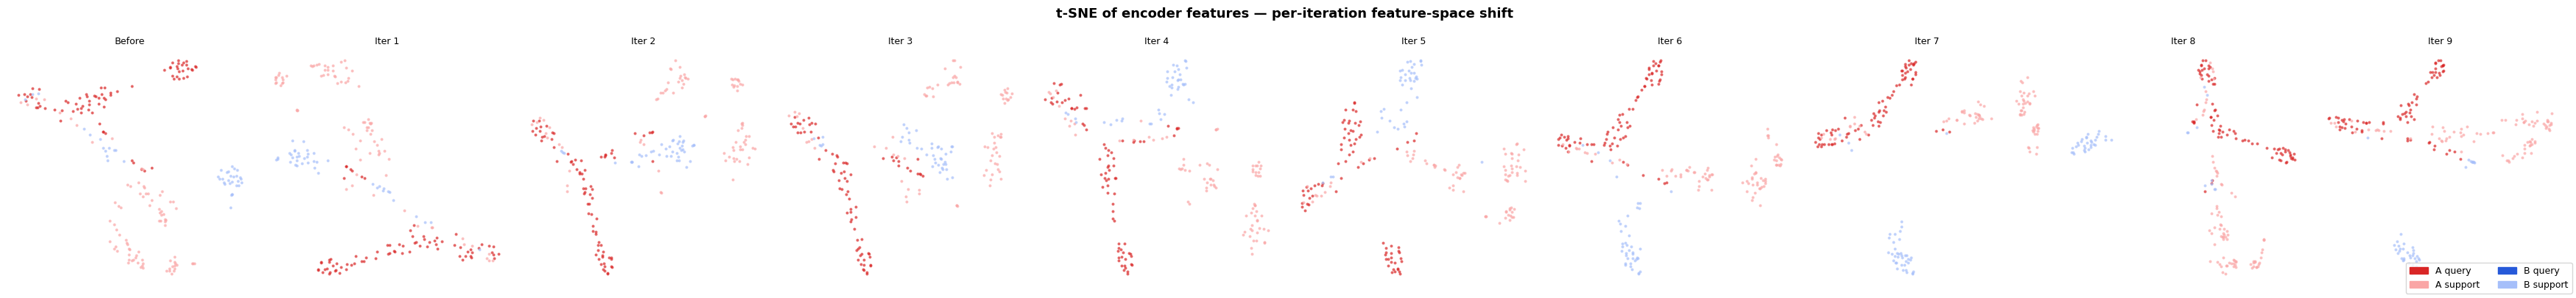

In [9]:
fig, axes = plt.subplots(1, NUM_ITER, figsize=(3.5*NUM_ITER, 4))
fig.suptitle('t-SNE of encoder features — per-iteration feature-space shift',
             fontsize=13, fontweight='bold')

for k, data in enumerate(tsne_data):
    ax = axes[k]
    if data is None:
        ax.set_visible(False)
        continue

    X_2d   = data['X_2d']
    groups = data['groups']

    for grp, colour in CLASS_COLOURS.items():
        idx = [i for i, g in enumerate(groups) if g == grp]
        if idx:
            ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
                       color=colour, s=8, alpha=0.7, linewidths=0)

    ax.set_title('Before' if k == 0 else f'Iter {k}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','bottom','left']].set_visible(False)

legend_patches = [mpatches.Patch(color=v, label=k.replace('_',' '))
                  for k, v in CLASS_COLOURS.items() if k != 'bg']
fig.legend(handles=legend_patches, loc='lower right', fontsize=9,
           ncol=2, framealpha=0.8)
plt.tight_layout()
plt.show()

## 10. Combined figure (paper style)

Reproduces Fig. 3: t-SNE (top) + segmentation (middle) + input overview (bottom).

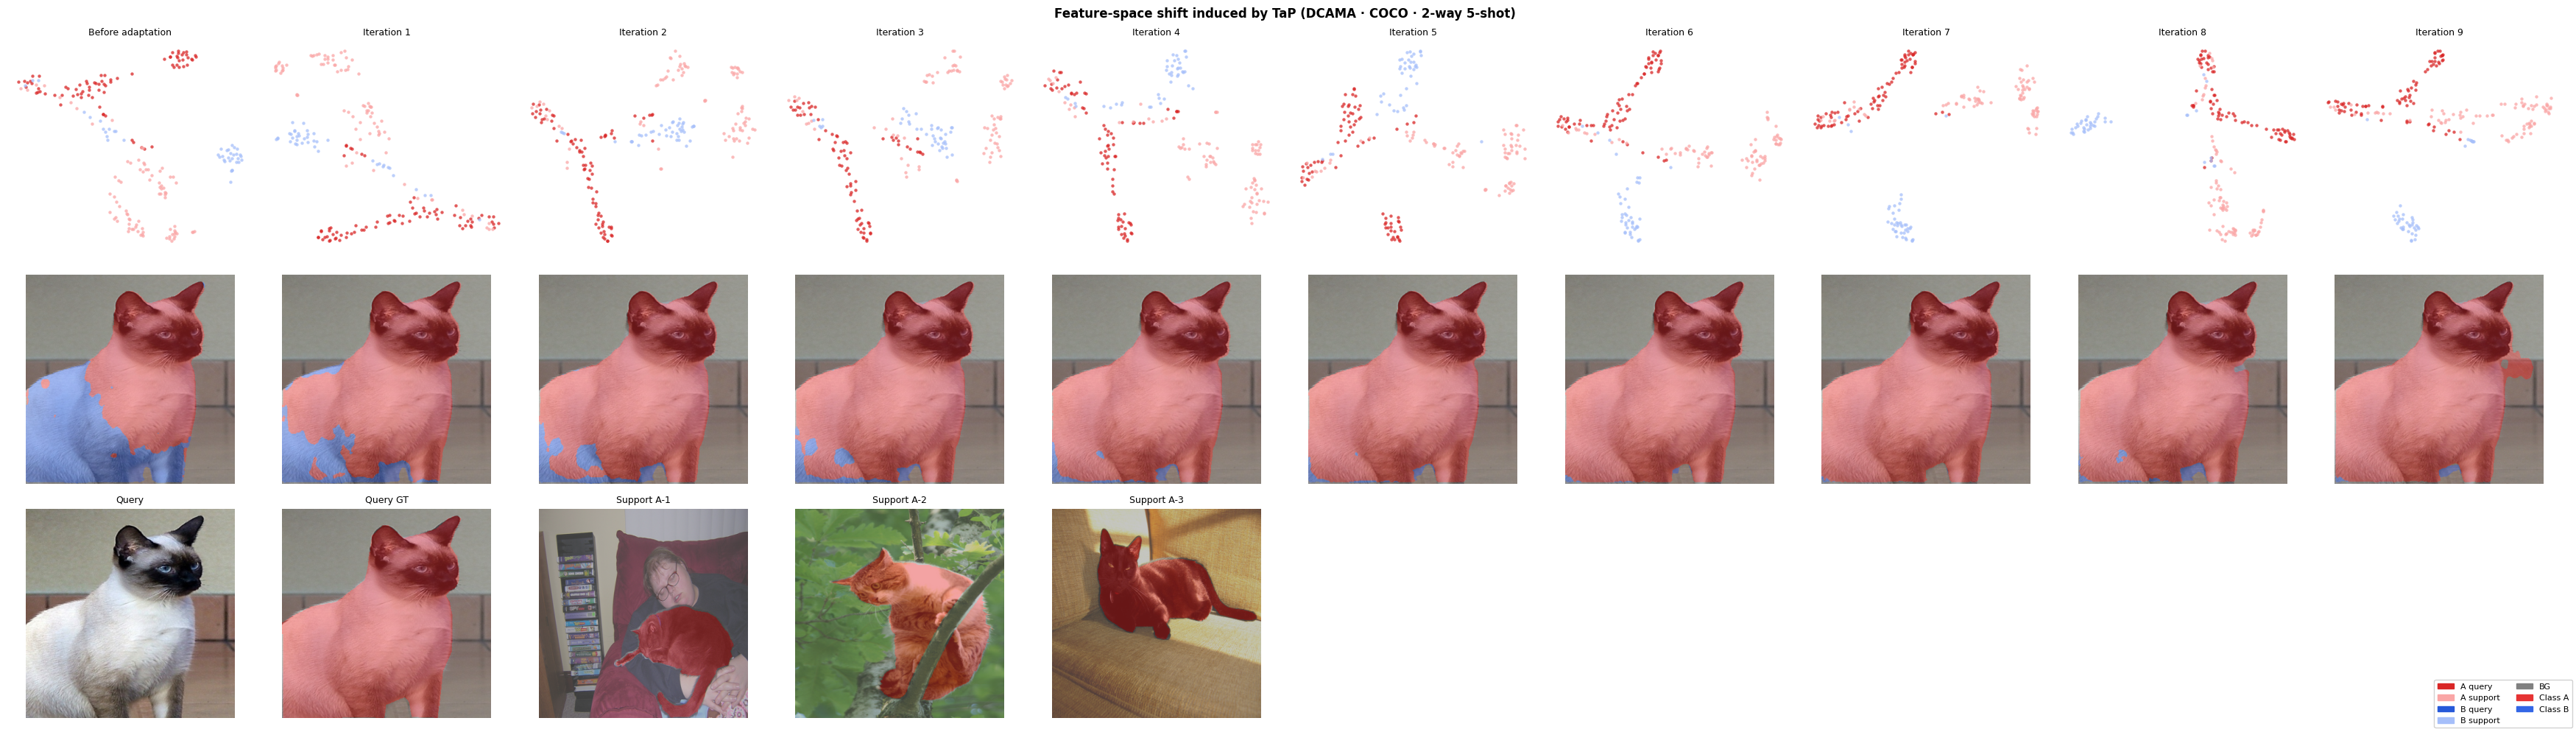

Saved feature_shift.png


In [10]:
# Show a subset of iterations to keep the figure manageable
show_iters = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   # adjust as needed
n_show     = len(show_iters)

s_imgs = images[1:]   # (N*K, 3, H, W)
class_a_imgs = s_imgs[:K_SHOTS]; class_b_imgs = s_imgs[K_SHOTS:]

fig, axes = plt.subplots(3, n_show, figsize=(3.5*n_show, 10))
fig.suptitle('Feature-space shift induced by TaP (DCAMA · COCO · 2-way 5-shot)',
             fontsize=12, fontweight='bold')

for col, k in enumerate(show_iters):
    rec  = records[k]
    data = tsne_data[k]

    # ── row 0: t-SNE ──────────────────────────────────────────────────────────
    ax = axes[0, col]
    if data is not None:
        X_2d, groups = data['X_2d'], data['groups']
        for grp, colour in CLASS_COLOURS.items():
            idx = [i for i, g in enumerate(groups) if g == grp]
            if idx:
                ax.scatter(X_2d[idx,0], X_2d[idx,1],
                           color=colour, s=10, alpha=0.75, linewidths=0)
    ax.set_title('Before adaptation' if k == 0 else f'Iteration {k}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','bottom','left']].set_visible(False)

    # ── row 1: segmentation prediction ────────────────────────────────────────
    axes[1, col].imshow(overlay(q_img, rec['pred'][0], orig_hw=(qh, qw)))
    axes[1, col].axis('off')

# ── row 2: input overview (static — same for all columns) ────────────────────
# Column 0: query image
axes[2, 0].imshow(denorm(q_img).permute(1,2,0))
axes[2, 0].set_title('Query', fontsize=9); axes[2, 0].axis('off')
# Column 1: query GT
axes[2, 1].imshow(overlay(q_img, q_gt_cpu, orig_hw=(qh, qw)))
axes[2, 1].set_title('Query GT', fontsize=9); axes[2, 1].axis('off')
# Columns 2+: support shots
for col in range(2, n_show):
    k_shot = col - 2
    if k_shot < K_SHOTS:
        sh, sw = dims[k_shot+1].tolist()
        axes[2, col].imshow(overlay(class_a_imgs[k_shot], s_gts[k_shot],
                                     orig_hw=(sh, sw)))
        axes[2, col].set_title(f'Support A-{k_shot+1}', fontsize=9)
    axes[2, col].axis('off')

# Legend
tsne_legend = [mpatches.Patch(color=v, label=k.replace('_',' '))
               for k, v in CLASS_COLOURS.items() if k != 'bg']
seg_legend  = [mpatches.Patch(color=SEG_PALETTE[i], label=l)
               for i, l in enumerate(['BG','Class A','Class B'])]
fig.legend(handles=tsne_legend + seg_legend, loc='lower right',
           fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(EPISODE_DIR, 'feature_shift.png'), dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved feature_shift.png')

## 11. Class separation over iterations

Quantify the shift with a simple **inter/intra-class distance ratio** in feature space.

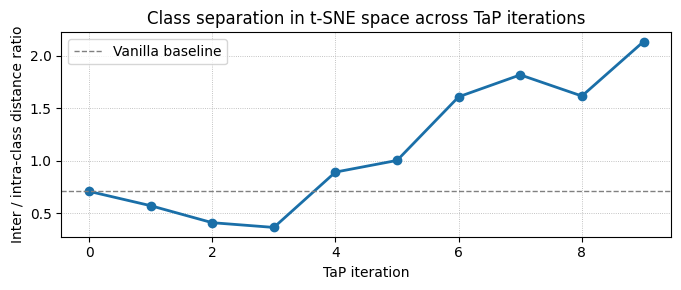

  Iter 0: 0.7094  (baseline)
  Iter 1: 0.5730  (-0.136)
  Iter 2: 0.4114  (-0.298)
  Iter 3: 0.3663  (-0.343)
  Iter 4: 0.8923  (+0.183)
  Iter 5: 1.0032  (+0.294)
  Iter 6: 1.6081  (+0.899)
  Iter 7: 1.8164  (+1.107)
  Iter 8: 1.6152  (+0.906)
  Iter 9: 2.1324  (+1.423)


In [11]:
def separation_score(data):
    """(mean inter-class distance) / (mean intra-class distance) — higher is better."""
    if data is None:
        return float('nan')
    X_2d, groups = data['X_2d'], np.array(data['groups'])
    a_idx = np.where((groups == 'A_query') | (groups == 'A_support'))[0]
    b_idx = np.where((groups == 'B_query') | (groups == 'B_support'))[0]
    if len(a_idx) < 2 or len(b_idx) < 2:
        return float('nan')

    A, B = X_2d[a_idx], X_2d[b_idx]
    centre_a, centre_b = A.mean(0), B.mean(0)

    inter = np.linalg.norm(centre_a - centre_b)
    intra = (np.linalg.norm(A - centre_a, axis=1).mean() +
             np.linalg.norm(B - centre_b, axis=1).mean()) / 2
    return inter / (intra + 1e-8)


scores = [separation_score(d) for d in tsne_data]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(NUM_ITER), scores, marker='o', lw=2, color='#1a6fa8')
ax.axhline(scores[0], color='grey', ls='--', lw=1, label='Vanilla baseline')
ax.set_xlabel('TaP iteration')
ax.set_ylabel('Inter / intra-class distance ratio')
ax.set_title('Class separation in t-SNE space across TaP iterations')
ax.legend(); ax.grid(True, ls=':', lw=0.6)
plt.tight_layout()
plt.show()

for k, s in enumerate(scores):
    change = f'({s-scores[0]:+.3f})' if k > 0 else '(baseline)'
    print(f'  Iter {k}: {s:.4f}  {change}')

## 12. Save plot data as JSON

Exports all t-SNE coordinates, segmentation overlays, and episode images to a single `feature_shift_data.json` file that can be loaded directly by an HTML/JS frontend.

In [12]:
# ── helpers ────────────────────────────────────────────────────────────────────
import base64
from io import BytesIO
from PIL import Image as PILImage
import json

def arr_to_b64(arr_hwc):
    """Float [0,1] HWC numpy array → PNG data URL."""
    img = PILImage.fromarray((np.clip(arr_hwc, 0, 1) * 255).astype('uint8'))
    buf = BytesIO()
    img.save(buf, format='PNG')
    return 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

def img_tensor_to_b64(img_chw, mask_hw=None, orig_hw=None):
    """Normalised (C,H,W) tensor → PNG data URL, optionally with mask overlay."""
    if mask_hw is not None:
        arr = overlay(img_chw, mask_hw, orig_hw=orig_hw)
    else:
        arr = denorm(img_chw).permute(1, 2, 0).numpy()
    return arr_to_b64(arr)

def pred_to_b64(pred_hw, img_chw, orig_hw):
    """Segmentation prediction → overlay PNG data URL."""
    return img_tensor_to_b64(img_chw, pred_hw, orig_hw=orig_hw)

# ── assemble JSON ──────────────────────────────────────────────────────────────
data = {
    "metadata": {
        "n_ways":          int(N_WAYS),
        "k_shots":         int(K_SHOTS),
        "num_iterations":  int(NUM_ITER),
        "n_pixels_sampled": int(N_PIX),
        "classes":         ["Class A", "Class B"],
        "groups": list(CLASS_COLOURS.keys()),
        "group_colours": {k: v.tolist() for k, v in CLASS_COLOURS.items()},
    },
    "iterations": [],
    "episode": {},
}

# ── per-iteration data ─────────────────────────────────────────────────────────
for k, (rec, d, score) in enumerate(zip(records, tsne_data, scores)):
    entry = {
        "index":            k,
        "separation_score": float(score) if not np.isnan(score) else None,
        "tsne":             None,
        "overlay_png":      pred_to_b64(rec['pred'][0], q_img, (qh, qw)),
    }
    if d is not None:
        entry["tsne"] = [
            {"x": float(x), "y": float(y), "group": g}
            for (x, y), g in zip(d["X_2d"], d["groups"])
        ]
    data["iterations"].append(entry)

# ── episode images ─────────────────────────────────────────────────────────────
s_imgs = images[1:]   # (N*K, C, H, W)
a_imgs = s_imgs[:K_SHOTS]
b_imgs = s_imgs[K_SHOTS:]

data["episode"]["query_png"]    = img_tensor_to_b64(q_img)
data["episode"]["query_gt_png"] = img_tensor_to_b64(q_img, q_gt_cpu, orig_hw=(qh, qw))
data["episode"]["support_a"]    = [
    img_tensor_to_b64(a_imgs[k],
                       s_gts[k],
                       orig_hw=dims[k+1].tolist())
    for k in range(K_SHOTS)
]
data["episode"]["support_b"]    = [
    img_tensor_to_b64(b_imgs[k],
                       s_gts[K_SHOTS+k],
                       orig_hw=dims[K_SHOTS+k+1].tolist())
    for k in range(K_SHOTS)
]

# ── write ──────────────────────────────────────────────────────────────────────
out_path = os.path.join(EPISODE_DIR, 'feature_shift_data.json')
with open(out_path, 'w') as f:
    json.dump(data, f, separators=(',', ':'))   # compact — no extra whitespace

size_mb = os.path.getsize(out_path) / 1e6
print(f'Saved {out_path}  ({size_mb:.1f} MB)')
print(f'  {len(data["iterations"])} iterations')
print(f'  t-SNE points per iter: {len(data["iterations"][0]["tsne"]) if data["iterations"][0]["tsne"] else 0}')
print(f'  Episode images: 1 query + {K_SHOTS} support-A + {K_SHOTS} support-B')


Saved assets/episode/feature_shift_data.json  (5.1 MB)
  10 iterations
  t-SNE points per iter: 204
  Episode images: 1 query + 3 support-A + 3 support-B
